# Giai đoạn 1 — Tiền xử lý dữ liệu trúng tuyển THPT (TTTH)

**Đầu vào:** `data/raw/TTTH_THPT_Cleaned.xlsx` — hồ sơ xét tuyển thật vào HUIT.
Mỗi dòng gồm: mã ngành trúng tuyển, mã tổ hợp, 3 cột điểm `M1/M2/M3` (điểm 3 môn theo
đúng thứ tự môn của tổ hợp), điểm ưu tiên và kết quả xét tuyển.

**Đầu ra:** `data/processed/TTTH_processed_flatten.csv` — mỗi dòng có `ma_nganh`, `to_hop_thi`
và **10 cột `diem_<Môn>`** (3 cột có giá trị, 7 cột `NaN`), khớp schema với dữ liệu khảo sát.

**Vai trò trong đề tài:** đây là nguồn **ĐIỂM THI ↔ NGÀNH THẬT** lớn nhất. Tập này **không có**
10 câu Likert / giới tính / mục tiêu nghề nghiệp — phần đó được sinh ở Giai đoạn 4.
Notebook này chỉ làm sạch và làm phẳng, **không sinh dữ liệu**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ── Thiết lập kiểu biểu đồ dùng chung cho toàn bộ báo cáo ────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

# Bảng màu thống nhất
C_THAT  = "#D64550"   # dữ liệu thật
C_GA    = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH  = "#3B7DD8"   # nhấn mạnh chính
C_CAM   = "#E8873A"   # nhấn mạnh phụ
C_TIM   = "#8E5FBF"
C_XAM   = "#AEB6BF"   # nền / mốc so sánh
C_DAM   = "#2C3E50"
C_KHOI  = ["#3B7DD8", "#E8873A", "#8E5FBF", "#19A2A2", "#D64550", "#C9A227", "#5D6D7E"]


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    # Ghi số ở cuối mỗi thanh ngang
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    # Ghi số trên đầu mỗi cột dọc
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    # Dòng chú giải nằm dưới hình — nêu kết luận rút ra từ biểu đồ.
    # Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    # dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai
    # bên đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def luu(fig, thu_muc, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 Đã lưu hình: {ten}")

TEN_NGANH = {
    7220201: "Ngôn ngữ Anh", 7220204: "Ngôn ngữ Trung Quốc", 7340101: "Quản trị kinh doanh",
    7340115: "Marketing", 7340120: "Kinh doanh quốc tế", 7340122: "Thương mại điện tử",
    7340123: "Kinh doanh thời trang và dệt may", 7340129: "Quản trị kinh doanh thực phẩm",
    7340201: "Tài chính ngân hàng", 7340205: "Công nghệ tài chính", 7340301: "Kế toán",
    7380101: "Luật", 7380107: "Luật kinh tế", 7420201: "Công nghệ sinh học",
    7460108: "Khoa học dữ liệu", 7480107: "Trí tuệ nhân tạo", 7480201: "Công nghệ thông tin",
    7480202: "An toàn thông tin", 7510202: "Công nghệ chế tạo máy",
    7510203: "Công nghệ kỹ thuật cơ điện tử", 7510301: "Công nghệ kỹ thuật điện - điện tử",
    7510303: "Công nghệ kỹ thuật điều khiển và TĐH", 7510401: "Công nghệ kỹ thuật hoá học",
    7510402: "Công nghệ vật liệu", 7510406: "Công nghệ kỹ thuật môi trường",
    7510601: "Quản lý Công nghiệp", 7510605: "Logistics và quản lý chuỗi cung ứng",
    7520115: "Kỹ thuật nhiệt", 7540101: "Công nghệ thực phẩm",
    7540105: "Công nghệ chế biến thuỷ sản", 7540106: "Đảm bảo chất lượng và ATTP",
    7540204: "Công nghệ dệt, may", 7810101: "Du lịch",
    7810103: "Quản trị dịch vụ du lịch và lữ hành", 7810201: "Quản trị khách sạn",
    7810202: "Quản trị nhà hàng và dịch vụ ăn uống", 7819009: "Khoa học dinh dưỡng và ẩm thực",
    7819010: "Khoa học chế biến món ăn", 7850101: "Quản lý tài nguyên và môi trường",
}
NGANH_TO_KHOI = {
    **{m: 0 for m in [7480201, 7480202, 7460108, 7480107]},
    **{m: 1 for m in [7340101, 7340115, 7340120, 7340122, 7340301, 7340201, 7340205,
                      7510605, 7510601, 7340123]},
    **{m: 2 for m in [7810103, 7810201, 7810202, 7810101, 7819009, 7819010]},
    **{m: 3 for m in [7510203, 7510202, 7520115, 7510301, 7510303, 7510401, 7510402, 7540204]},
    **{m: 4 for m in [7540101, 7540106, 7340129, 7540105, 7420201, 7510406, 7850101]},
    **{m: 5 for m in [7380101, 7380107]},
    **{m: 6 for m in [7220201, 7220204]},
}
TEN_KHOI = {
    0: "CNTT & Máy tính", 1: "Kinh doanh & Quản lý", 2: "Du lịch, Khách sạn & Ẩm thực",
    3: "Kỹ thuật & Công nghệ", 4: "Thực phẩm, Sinh học & Môi trường", 5: "Luật", 6: "Ngoại ngữ",
}

RAW_PATH    = Path("../data/raw/TTTH_THPT_Cleaned.xlsx")
OUTPUT_PATH = Path("../data/processed/TTTH_processed_flatten.csv")
HINH_DIR    = Path("../data/processed/01_flatten")
HINH_DIR.mkdir(parents=True, exist_ok=True)

df_goc = pd.read_excel(RAW_PATH)
SO_DONG_GOC = len(df_goc)

print(f"Số hồ sơ thô : {SO_DONG_GOC:,}")
print(f"Số cột       : {df_goc.shape[1]}")
print(f"Tên cột      : {list(df_goc.columns)}")
print(f"\nSố ô trống theo cột: {df_goc.isna().sum().sum()} (toàn bộ bảng)")
df_goc.head()

Số hồ sơ thô : 18,024
Số cột       : 8
Tên cột      : ['SBD', 'Mã ngành trúng tuyển', 'Mã tổ hợp trúng tuyển', 'DUT', 'M1', 'M2', 'M3', 'KQ']

Số ô trống theo cột: 0 (toàn bộ bảng)


,SBD,Mã ngành trúng tuyển,Mã tổ hợp trúng tuyển,DUT,M1,M2,M3,KQ
0,2035029,7540101,B00,0.25,8.25,8.25,8.0,TT
1,2075656,7380107,A00,0.00,8.00,7.50,6.5,TT
2,2040618,7510202,D01,0.25,7.00,8.00,4.8,TT
3,2042637,7810202,D01,0.00,5.75,7.80,7.2,TT
4,42010058,7340201,A01,0.75,8.00,8.00,7.6,TT


## 1. Làm sạch dữ liệu

| Bước | Việc | Lý do |
|---|---|---|
| 1 | Giữ `KQ == 'TT'` | Chỉ lấy thí sinh **trúng tuyển** (`KTT` = không trúng tuyển) |
| 2 | Bỏ tổ hợp `D10` | Chưa xác định được ánh xạ 3 môn của tổ hợp này |
| 3 | Chuyển 3 mã ngành cũ sang mã mới | Ngành đổi mã qua các năm; chỉ chuyển khi tổ hợp hợp lệ với ngành mới |
| 4 | Giữ đúng 39 ngành trong phạm vi đề tài | Loại ngành ngoài danh mục nghiên cứu |

In [2]:
buoc = [("Dữ liệu thô", SO_DONG_GOC)]
df = df_goc.copy()

df = df[df["KQ"] == "TT"].copy()
buoc.append(("Loại hồ sơ không trúng tuyển", len(df)))

df = df[df["Mã tổ hợp trúng tuyển"] != "D10"].copy()
buoc.append(("Loại tổ hợp D10", len(df)))

remap_rules = {   # mã cũ -> (mã mới, tổ hợp hợp lệ của ngành mới)
    7520311: (7510401, {"B00", "B08", "A00", "D07"}),
    7620303: (7540105, {"B00", "B08", "A00", "D07"}),
    7540110: (7540106, {"B00", "B08", "A00", "D07"}),
}
bo_di = []
for ma_cu, (ma_moi, hop_le) in remap_rules.items():
    m = df["Mã ngành trúng tuyển"] == ma_cu
    bo_di += df[m & (~df["Mã tổ hợp trúng tuyển"].isin(hop_le))].index.tolist()
    df.loc[m & (df["Mã tổ hợp trúng tuyển"].isin(hop_le)), "Mã ngành trúng tuyển"] = ma_moi
df = df.drop(index=bo_di)
buoc.append(("Chuyển 3 mã ngành cũ", len(df)))

DANH_SACH_39 = set(TEN_NGANH)
assert len(DANH_SACH_39) == 39
df = df[df["Mã ngành trúng tuyển"].isin(DANH_SACH_39)].copy()
buoc.append(("Giữ 39 ngành trong phạm vi", len(df)))

bang_buoc = pd.DataFrame(buoc, columns=["Bước xử lý", "Số hồ sơ còn lại"])
bang_buoc["Bị loại"] = -bang_buoc["Số hồ sơ còn lại"].diff().fillna(0).astype(int)
bang_buoc["Còn lại (%)"] = (bang_buoc["Số hồ sơ còn lại"] / SO_DONG_GOC * 100).round(1)
print("BẢNG 1.1 — Kết quả từng bước làm sạch\n")
print(bang_buoc.to_string(index=False))

BẢNG 1.1 — Kết quả từng bước làm sạch

                  Bước xử lý  Số hồ sơ còn lại  Bị loại  Còn lại (%)
                 Dữ liệu thô             18024        0        100.0
Loại hồ sơ không trúng tuyển             17272      752         95.8
             Loại tổ hợp D10             16309      963         90.5
        Chuyển 3 mã ngành cũ             16250       59         90.2
  Giữ 39 ngành trong phạm vi             15888      362         88.1


   💾 Đã lưu hình: hinh_1_1_pheu_lam_sach.png


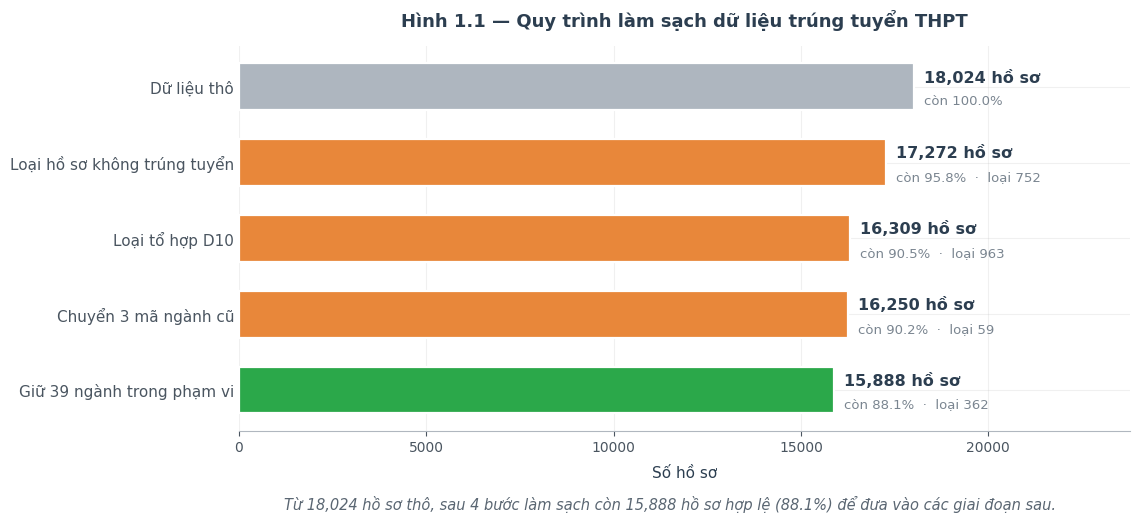

In [3]:
# ═══════════ HÌNH 1.1 — Phễu làm sạch dữ liệu ═══════════
fig, ax = plt.subplots(figsize=(11.5, 5))

y = np.arange(len(bang_buoc))[::-1]
mau = [C_XAM, C_CAM, C_CAM, C_CAM, C_GA]
ax.barh(y, bang_buoc["Số hồ sơ còn lại"], height=0.62, color=mau,
        edgecolor="white", linewidth=1.6)

for yy, n, loai, pct in zip(y, bang_buoc["Số hồ sơ còn lại"], bang_buoc["Bị loại"],
                            bang_buoc["Còn lại (%)"]):
    ax.text(n + SO_DONG_GOC * 0.015, yy + 0.13, f"{n:,} hồ sơ",
            va="center", fontsize=11.5, fontweight="bold", color=C_DAM)
    ghi = f"còn {pct:.1f}%" + (f"  ·  loại {loai:,}" if loai else "")
    ax.text(n + SO_DONG_GOC * 0.015, yy - 0.19, ghi,
            va="center", fontsize=9.5, color="#7A8590")

ax.set_yticks(y); ax.set_yticklabels(bang_buoc["Bước xử lý"], fontsize=11)
ax.set_xlim(0, SO_DONG_GOC * 1.32)
ax.set_xlabel("Số hồ sơ")
ax.set_title("Hình 1.1 — Quy trình làm sạch dữ liệu trúng tuyển THPT")
ax.grid(axis="x", alpha=0.18); ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)

luu(fig, HINH_DIR, "hinh_1_1_pheu_lam_sach.png",
    f"Từ {SO_DONG_GOC:,} hồ sơ thô, sau 4 bước làm sạch còn {len(df):,} hồ sơ hợp lệ "
    f"({len(df)/SO_DONG_GOC:.1%}) để đưa vào các giai đoạn sau.")
plt.show()

## 2. Làm phẳng M1/M2/M3 thành 10 cột điểm theo môn

Mỗi tổ hợp quy định thứ tự 3 môn. Ví dụ `A00 = [Toán, Lý, Hoá]` nghĩa là
`M1 → diem_Toan`, `M2 → diem_Ly`, `M3 → diem_Hoa`. Bảy môn còn lại để trống (`NaN`) —
XGBoost xử lý được giá trị thiếu nên **không điền giá trị thay thế**.

In [4]:
TO_HOP_MAP = {
    "A00": ["Toan", "Ly",  "Hoa"],   "A01": ["Toan", "Ly",  "Anh"],
    "B00": ["Toan", "Hoa", "Sinh"],  "B08": ["Toan", "Sinh", "Anh"],
    "C00": ["Van",  "Su",  "Dia"],   "C01": ["Van",  "Toan", "Ly"],
    "C02": ["Van",  "Toan", "Hoa"],  "C03": ["Van",  "Toan", "Su"],
    "D01": ["Toan", "Van", "Anh"],   "D07": ["Toan", "Hoa", "Anh"],
    "D09": ["Toan", "Su",  "Anh"],   "D14": ["Van",  "Anh", "Su"],
    "D15": ["Van",  "Dia", "Anh"],   "X01": ["Toan", "Van", "Gdktpl"],
    "X26": ["Toan", "Tin", "Anh"],
}
MON = ["Toan", "Ly", "Hoa", "Anh", "Van", "Su", "Sinh", "Dia", "Gdktpl", "Tin"]
DIEM_COLS = [f"diem_{m}" for m in MON]

la = set(df["Mã tổ hợp trúng tuyển"]) - set(TO_HOP_MAP)
assert not la, f"Tổ hợp chưa khai báo: {la}"

for m in MON:
    df[f"diem_{m}"] = np.nan
for th, ds in TO_HOP_MAP.items():
    mask = df["Mã tổ hợp trúng tuyển"] == th
    if mask.any():
        for i, m in enumerate(ds):
            df.loc[mask, f"diem_{m}"] = df.loc[mask, f"M{i+1}"].values

df_final = (df[["Mã ngành trúng tuyển", "Mã tổ hợp trúng tuyển"] + DIEM_COLS]
            .rename(columns={"Mã ngành trúng tuyển": "ma_nganh",
                             "Mã tổ hợp trúng tuyển": "to_hop_thi"})
            .reset_index(drop=True))

assert (df_final[DIEM_COLS].notna().sum(axis=1) == 3).all(), "Mỗi dòng phải có đúng 3 điểm"
assert df_final["ma_nganh"].isin(DANH_SACH_39).all()
assert df_final[DIEM_COLS].stack().between(0, 10).all(), "Điểm phải trong [0, 10]"

df_final["ma_khoi"] = df_final["ma_nganh"].map(NGANH_TO_KHOI)
df_final["diem_tb"] = df_final[DIEM_COLS].mean(axis=1)

print(f"✅ Kiểm tra đạt — {len(df_final):,} hồ sơ, mỗi hồ sơ đúng 3 điểm môn, 0 ≤ điểm ≤ 10")
print(f"   Số ngành có dữ liệu : {df_final['ma_nganh'].nunique()} / 39")
print(f"   Tổ hợp xuất hiện    : {sorted(df_final['to_hop_thi'].unique())}")
df_final.head()

✅ Kiểm tra đạt — 15,888 hồ sơ, mỗi hồ sơ đúng 3 điểm môn, 0 ≤ điểm ≤ 10
   Số ngành có dữ liệu : 34 / 39
   Tổ hợp xuất hiện    : ['A00', 'A01', 'B00', 'D01', 'D07', 'D09', 'D15']


,ma_nganh,to_hop_thi,diem_Toan,diem_Ly,diem_Hoa,diem_Anh,diem_Van,diem_Su,diem_Sinh,diem_Dia,diem_Gdktpl,diem_Tin,ma_khoi,diem_tb
0,7540101,B00,8.25,NaN,8.25,NaN,NaN,NaN,8.0,NaN,NaN,NaN,4,8.166667
1,7380107,A00,8.00,7.5,6.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,7.333333
2,7510202,D01,7.00,NaN,NaN,4.8,8.0,NaN,NaN,NaN,NaN,NaN,3,6.600000
3,7810202,D01,5.75,NaN,NaN,7.2,7.8,NaN,NaN,NaN,NaN,NaN,2,6.916667
4,7340201,A01,8.00,8.0,NaN,7.6,NaN,NaN,NaN,NaN,NaN,NaN,1,7.866667


## 3. Thống kê mô tả điểm thi

In [5]:
mo_ta = df_final[DIEM_COLS].describe().T
mo_ta.insert(0, "Số thí sinh thi", df_final[DIEM_COLS].notna().sum())
mo_ta.insert(1, "Thiếu (%)", (df_final[DIEM_COLS].isna().mean() * 100).round(1))
mo_ta = mo_ta.drop(columns=["count"])
mo_ta.columns = ["Số thí sinh thi", "Thiếu (%)", "Trung bình", "Độ lệch chuẩn",
                 "Nhỏ nhất", "Phân vị 25", "Trung vị", "Phân vị 75", "Lớn nhất"]
mo_ta.index = [c.replace("diem_", "") for c in mo_ta.index]

print("BẢNG 1.2 — Thống kê mô tả điểm thi theo môn\n")
print(mo_ta.round(2).to_string())
print(f"\nĐiểm trung bình 3 môn của toàn bộ hồ sơ: "
      f"{df_final['diem_tb'].mean():.2f} ± {df_final['diem_tb'].std():.2f}")

BẢNG 1.2 — Thống kê mô tả điểm thi theo môn

        Số thí sinh thi  Thiếu (%)  Trung bình  Độ lệch chuẩn  Nhỏ nhất  Phân vị 25  Trung vị  Phân vị 75  Lớn nhất
Toan              15620        1.7        7.37           0.83      3.75        7.00      7.50        8.00       9.5
Ly                 7591       52.2        7.20           0.90      3.00        6.75      7.25        7.75       9.6
Hoa                7473       53.0        7.40           0.81      3.60        7.00      7.50        8.00       9.5
Anh                9333       41.3        7.37           1.03      2.20        6.80      7.40        8.00      10.0
Van                6443       59.4        6.93           1.10      2.80        6.25      7.00        7.75       9.6
Su                  115       99.3        7.45           0.95      5.00        6.80      7.60        8.00       9.8
Sinh                821       94.8        7.06           0.92      3.50        6.50      7.20        7.75       9.5
Dia                 268    

   💾 Đã lưu hình: hinh_1_2_thieu_diem_theo_mon.png


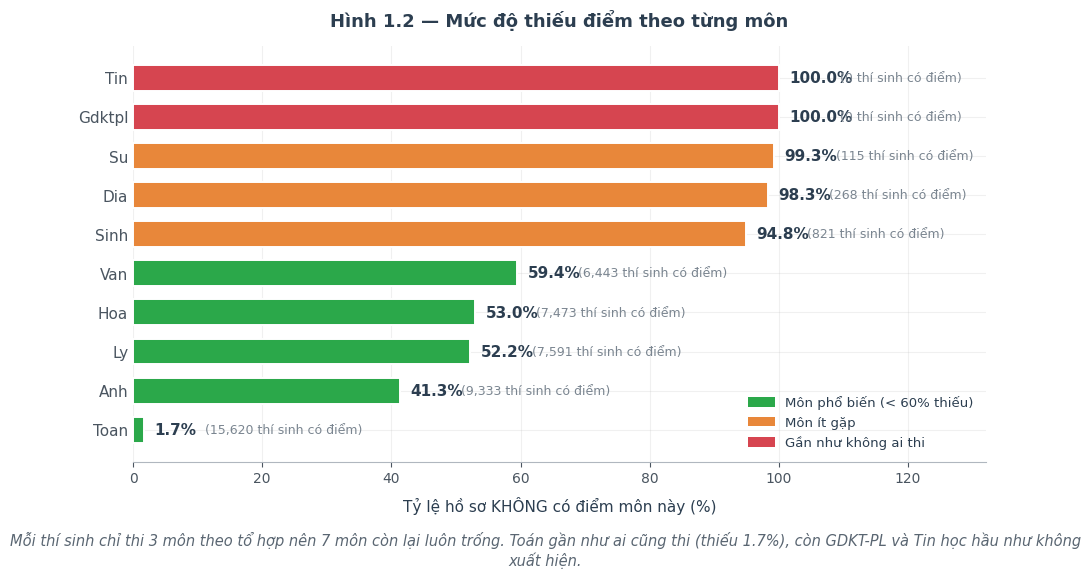

In [6]:
# ═══════════ HÌNH 1.2 — Mức độ thiếu điểm theo môn ═══════════
fig, ax = plt.subplots(figsize=(11, 5.4))

thieu = (df_final[DIEM_COLS].isna().mean() * 100).sort_values()
ten = [c.replace("diem_", "") for c in thieu.index]
mau = [C_GA if v < 60 else (C_CAM if v < 99.5 else C_THAT) for v in thieu.values]

ax.barh(range(len(thieu)), thieu.values, height=0.66, color=mau,
        edgecolor="white", linewidth=1.4)
for i, (v, c) in enumerate(zip(thieu.values, thieu.index)):
    n_co = int(df_final[c].notna().sum())
    ax.text(v + 1.6, i, f"{v:.1f}%", va="center", fontsize=11, fontweight="bold", color=C_DAM)
    ax.text(v + 9.5, i, f"({n_co:,} thí sinh có điểm)", va="center", fontsize=9, color="#7A8590")

ax.set_yticks(range(len(thieu))); ax.set_yticklabels(ten, fontsize=11)
ax.set_xlim(0, 132); ax.set_xlabel("Tỷ lệ hồ sơ KHÔNG có điểm môn này (%)")
ax.set_title("Hình 1.2 — Mức độ thiếu điểm theo từng môn")
ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)
ax.legend(handles=[Patch(facecolor=C_GA, label="Môn phổ biến (< 60% thiếu)"),
                   Patch(facecolor=C_CAM, label="Môn ít gặp"),
                   Patch(facecolor=C_THAT, label="Gần như không ai thi")],
          loc="lower right", fontsize=9.5)

luu(fig, HINH_DIR, "hinh_1_2_thieu_diem_theo_mon.png",
    "Mỗi thí sinh chỉ thi 3 môn theo tổ hợp nên 7 môn còn lại luôn trống. "
    "Toán gần như ai cũng thi (thiếu 1.7%), còn GDKT-PL và Tin học hầu như không xuất hiện.")
plt.show()

/var/folders/mq/2fy07gmj1xbchl5_vpcj4pmh0000gn/T/ipykernel_36141/3695863131.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(du, vert=False, patch_artist=True, widths=0.62, showfliers=False,


   💾 Đã lưu hình: hinh_1_3_phan_bo_diem.png


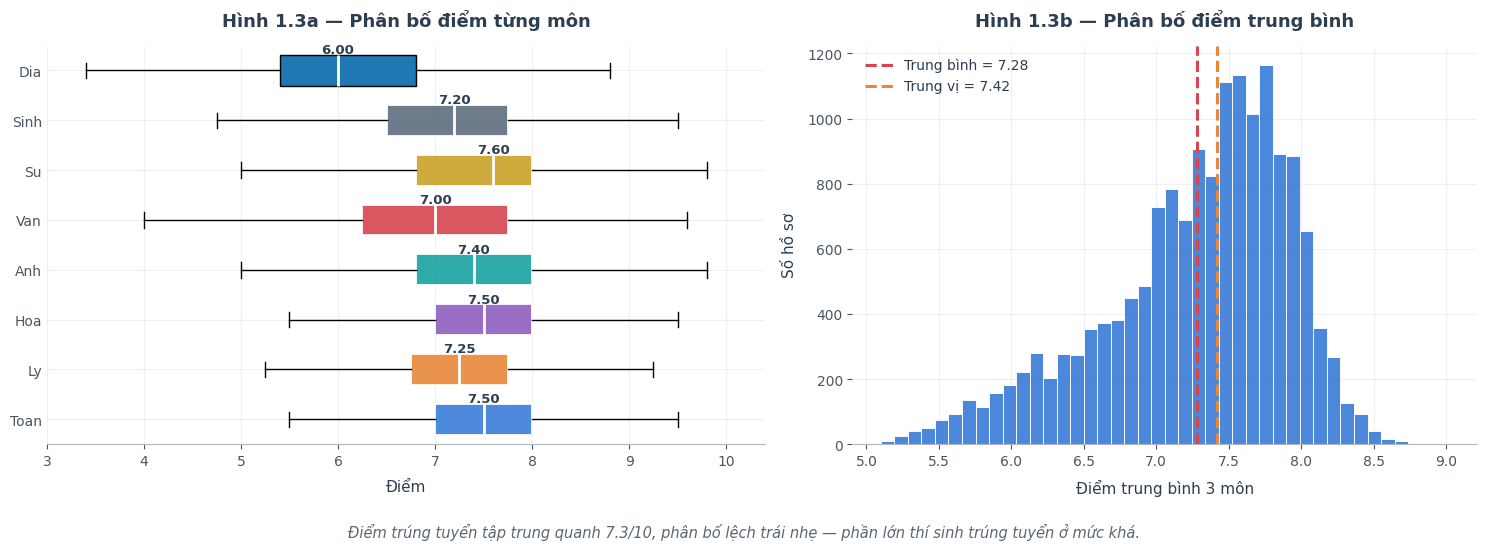

In [7]:
# ═══════════ HÌNH 1.3 — Phân bố điểm ═══════════
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.15, 1]})

# (a) Boxplot từng môn — chỉ các môn có đủ dữ liệu
ax = axes[0]
co_du = [c for c in DIEM_COLS if df_final[c].notna().sum() >= 50]
du = [df_final[c].dropna().values for c in co_du]
bp = ax.boxplot(du, vert=False, patch_artist=True, widths=0.62, showfliers=False,
                labels=[c.replace("diem_", "") for c in co_du],
                medianprops={"color": "white", "lw": 2})
for p, m in zip(bp["boxes"], [C_XANH, C_CAM, C_TIM, "#19A2A2", C_THAT, "#C9A227", "#5D6D7E"]):
    p.set_facecolor(m); p.set_alpha(0.9); p.set_edgecolor("white"); p.set_linewidth(1.4)
for i, d in enumerate(du):
    ax.text(np.median(d), i + 1.34, f"{np.median(d):.2f}", ha="center",
            fontsize=9.5, fontweight="bold", color=C_DAM)
ax.set_xlabel("Điểm"); ax.set_xlim(3, 10.4)
ax.set_title("Hình 1.3a — Phân bố điểm từng môn")
ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

# (b) Histogram điểm trung bình
ax = axes[1]
ax.hist(df_final["diem_tb"], bins=42, color=C_XANH, edgecolor="white", linewidth=0.7, alpha=0.92)
tb, tv = df_final["diem_tb"].mean(), df_final["diem_tb"].median()
ax.axvline(tb, color=C_THAT, ls="--", lw=2.2, label=f"Trung bình = {tb:.2f}")
ax.axvline(tv, color=C_CAM, ls="--", lw=2.2, label=f"Trung vị = {tv:.2f}")
ax.set_xlabel("Điểm trung bình 3 môn"); ax.set_ylabel("Số hồ sơ")
ax.set_title("Hình 1.3b — Phân bố điểm trung bình")
ax.legend(loc="upper left"); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, HINH_DIR, "hinh_1_3_phan_bo_diem.png",
    f"Điểm trúng tuyển tập trung quanh {tb:.1f}/10, phân bố lệch trái nhẹ — "
    "phần lớn thí sinh trúng tuyển ở mức khá.")
plt.show()

## 4. Phân bố theo ngành — mức độ mất cân bằng dữ liệu

Đây là thông tin quan trọng nhất của giai đoạn này: dữ liệu **rất mất cân bằng** giữa các ngành,
và có những ngành **hoàn toàn không xuất hiện**. Hai điều này chi phối toàn bộ thiết kế ở các
giai đoạn sau.

In [8]:
vc = df_final["ma_nganh"].value_counts()
thieu_nganh = sorted(DANH_SACH_39 - set(vc.index))

bang_nganh = pd.DataFrame({"Số hồ sơ": [vc.get(m, 0) for m in TEN_NGANH]},
                          index=[TEN_NGANH[m] for m in TEN_NGANH])
bang_nganh.insert(0, "Khối ngành", [TEN_KHOI[NGANH_TO_KHOI[m]] for m in TEN_NGANH])
bang_nganh["Tỷ lệ (%)"] = (bang_nganh["Số hồ sơ"] / len(df_final) * 100).round(2)
bang_nganh = bang_nganh.sort_values("Số hồ sơ", ascending=False)

print(f"BẢNG 1.3 — Số hồ sơ TTTH theo 39 ngành\n")
print(bang_nganh.to_string())
print(f"\nNhiều nhất : {vc.max():,} hồ sơ  ({TEN_NGANH[vc.idxmax()]})")
print(f"Ít nhất    : {vc.min():,} hồ sơ  ({TEN_NGANH[vc.idxmin()]})")
print(f"Chênh lệch : {vc.max()/vc.min():.0f} lần")
print(f"\n⚠️  {len(thieu_nganh)} ngành KHÔNG có hồ sơ TTTH nào:")
for m in thieu_nganh:
    print(f"      {TEN_NGANH[m]:<40} (khối: {TEN_KHOI[NGANH_TO_KHOI[m]]})")

BẢNG 1.3 — Số hồ sơ TTTH theo 39 ngành

                                                            Khối ngành  Số hồ sơ  Tỷ lệ (%)
Công nghệ thông tin                                    CNTT & Máy tính      1866      11.74
Quản trị kinh doanh                               Kinh doanh & Quản lý      1010       6.36
Công nghệ thực phẩm                   Thực phẩm, Sinh học & Môi trường       948       5.97
Tài chính ngân hàng                               Kinh doanh & Quản lý       904       5.69
Kinh doanh quốc tế                                Kinh doanh & Quản lý       863       5.43
Marketing                                         Kinh doanh & Quản lý       838       5.27
Kế toán                                           Kinh doanh & Quản lý       827       5.21
Luật kinh tế                                                      Luật       809       5.09
Công nghệ kỹ thuật điều khiển và TĐH              Kỹ thuật & Công nghệ       626       3.94
An toàn thông tin                       

   💾 Đã lưu hình: hinh_1_4_ho_so_theo_39_nganh.png


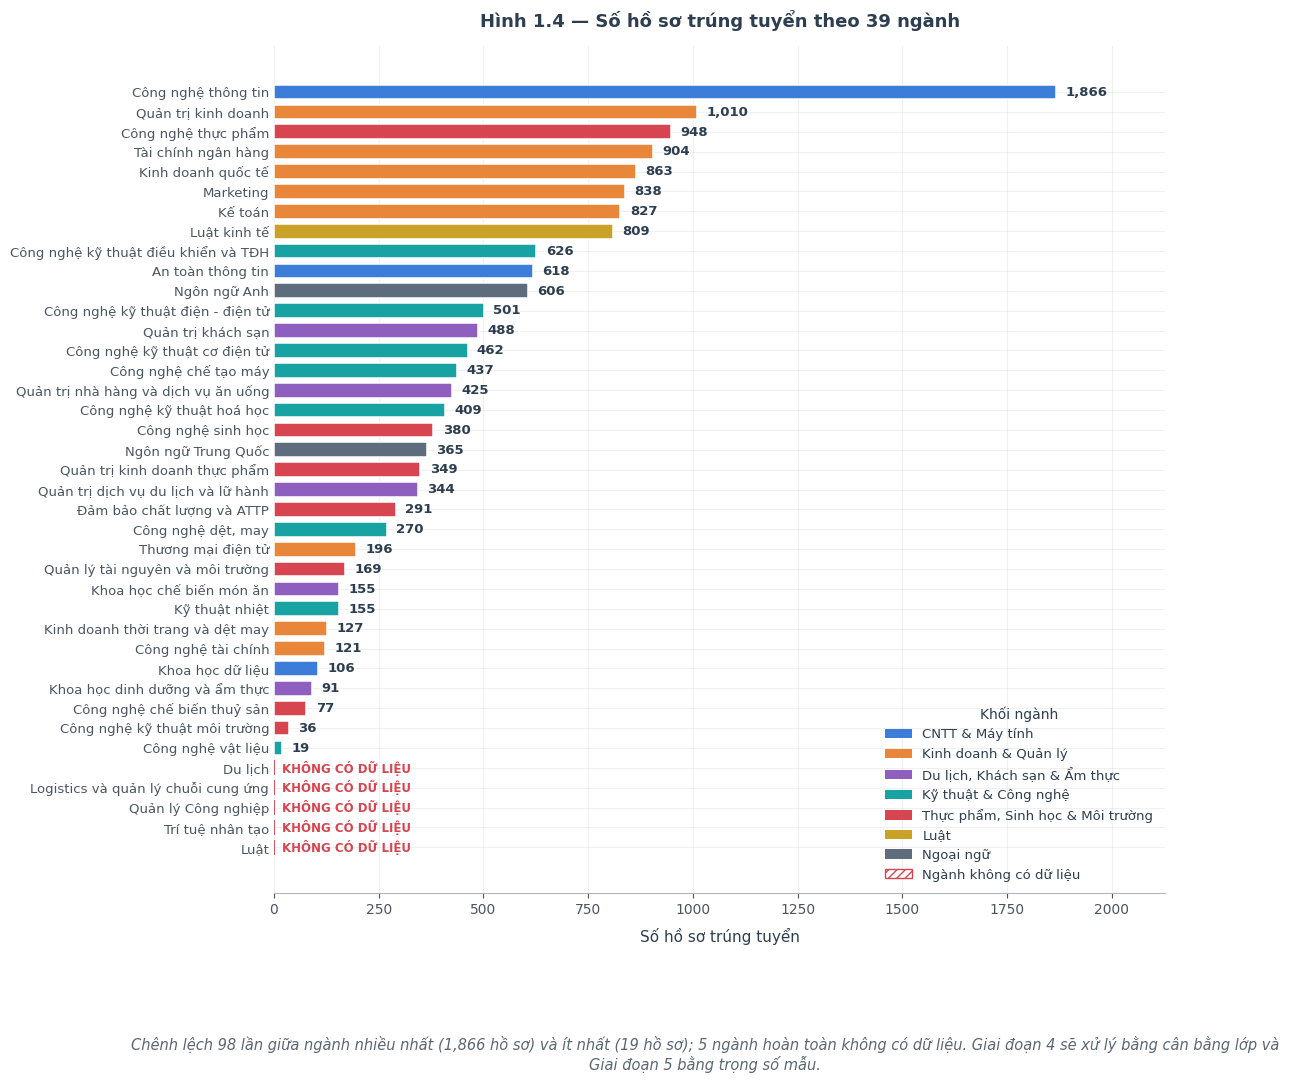

In [9]:
# ═══════════ HÌNH 1.4 — Số hồ sơ theo 39 ngành ═══════════
fig, ax = plt.subplots(figsize=(11.5, 11))

thu_tu = sorted(TEN_NGANH, key=lambda m: vc.get(m, 0))
gt  = [vc.get(m, 0) for m in thu_tu]
mau = [C_KHOI[NGANH_TO_KHOI[m]] for m in thu_tu]

bars = ax.barh(range(39), gt, height=0.74, color=mau, edgecolor="white", linewidth=1.1)
for i, m in enumerate(thu_tu):
    if m in thieu_nganh:
        bars[i].set_facecolor("white"); bars[i].set_edgecolor(C_THAT)
        bars[i].set_hatch("////"); bars[i].set_linewidth(1.3)
        ax.text(18, i, "KHÔNG CÓ DỮ LIỆU", va="center", fontsize=8.5,
                fontweight="bold", color=C_THAT)
    else:
        ax.text(gt[i] + vc.max() * 0.012, i, f"{gt[i]:,}", va="center",
                fontsize=9.5, fontweight="bold", color=C_DAM)

ax.set_yticks(range(39)); ax.set_yticklabels([TEN_NGANH[m] for m in thu_tu], fontsize=9.5)
ax.set_xlabel("Số hồ sơ trúng tuyển"); ax.set_xlim(0, vc.max() * 1.14)
ax.set_title("Hình 1.4 — Số hồ sơ trúng tuyển theo 39 ngành")
ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)
ax.legend(handles=[Patch(facecolor=C_KHOI[i], label=TEN_KHOI[i]) for i in range(7)]
                  + [Patch(facecolor="white", hatch="////", edgecolor=C_THAT,
                           label="Ngành không có dữ liệu")],
          loc="lower right", fontsize=9.5, title="Khối ngành", title_fontsize=10)

luu(fig, HINH_DIR, "hinh_1_4_ho_so_theo_39_nganh.png",
    f"Chênh lệch {vc.max()/vc.min():.0f} lần giữa ngành nhiều nhất ({vc.max():,} hồ sơ) và ít nhất "
    f"({vc.min()} hồ sơ); {len(thieu_nganh)} ngành hoàn toàn không có dữ liệu. "
    "Giai đoạn 4 sẽ xử lý bằng cân bằng lớp và Giai đoạn 5 bằng trọng số mẫu.")
plt.show()

/var/folders/mq/2fy07gmj1xbchl5_vpcj4pmh0000gn/T/ipykernel_36141/1144309214.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(du, vert=False, patch_artist=True, widths=0.62, showfliers=False,


   💾 Đã lưu hình: hinh_1_5_khoi_nganh_va_diem.png


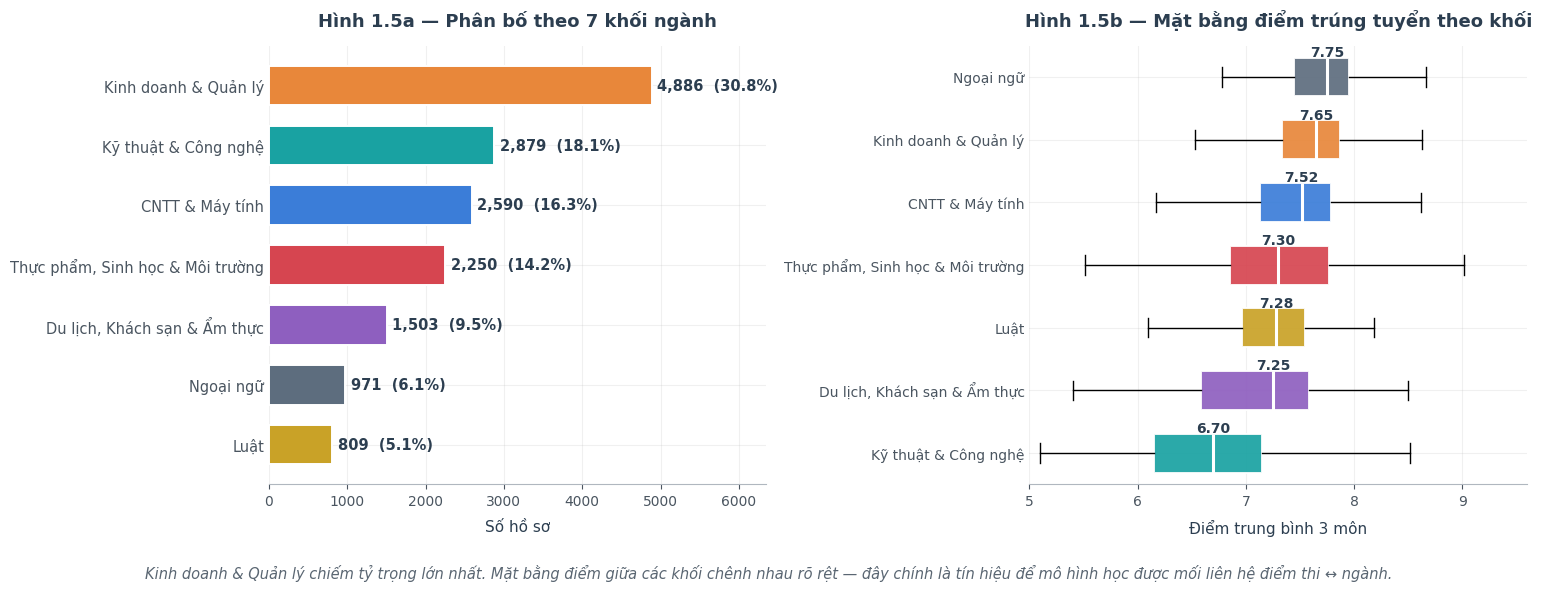

In [10]:
# ═══════════ HÌNH 1.5 — Theo khối ngành & mặt bằng điểm ═══════════
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.6))

# (a) Số hồ sơ theo 7 khối
ax = axes[0]
kh = df_final["ma_khoi"].value_counts().sort_values()
ax.barh(range(len(kh)), kh.values, height=0.66,
        color=[C_KHOI[i] for i in kh.index], edgecolor="white", linewidth=1.4)
for i, (idx, v) in enumerate(zip(kh.index, kh.values)):
    ax.text(v + kh.max() * 0.015, i, f"{v:,}  ({v/len(df_final):.1%})",
            va="center", fontsize=10.5, fontweight="bold", color=C_DAM)
ax.set_yticks(range(len(kh))); ax.set_yticklabels([TEN_KHOI[i] for i in kh.index], fontsize=10.5)
ax.set_xlim(0, kh.max() * 1.3); ax.set_xlabel("Số hồ sơ")
ax.set_title("Hình 1.5a — Phân bố theo 7 khối ngành")
ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

# (b) Mặt bằng điểm theo khối
ax = axes[1]
thu_tu_k = df_final.groupby("ma_khoi")["diem_tb"].median().sort_values().index
du = [df_final.loc[df_final.ma_khoi == i, "diem_tb"].values for i in thu_tu_k]
bp = ax.boxplot(du, vert=False, patch_artist=True, widths=0.62, showfliers=False,
                labels=[TEN_KHOI[i] for i in thu_tu_k],
                medianprops={"color": "white", "lw": 2.2})
for p, i in zip(bp["boxes"], thu_tu_k):
    p.set_facecolor(C_KHOI[i]); p.set_alpha(0.92); p.set_edgecolor("white"); p.set_linewidth(1.4)
for i, d in enumerate(du):
    ax.text(np.median(d), i + 1.33, f"{np.median(d):.2f}", ha="center",
            fontsize=10, fontweight="bold", color=C_DAM)
ax.set_xlabel("Điểm trung bình 3 môn"); ax.set_xlim(5, 9.6)
ax.set_title("Hình 1.5b — Mặt bằng điểm trúng tuyển theo khối")
ax.tick_params(axis="y", labelsize=10, length=0); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, HINH_DIR, "hinh_1_5_khoi_nganh_va_diem.png",
    "Kinh doanh & Quản lý chiếm tỷ trọng lớn nhất. Mặt bằng điểm giữa các khối chênh nhau "
    "rõ rệt — đây chính là tín hiệu để mô hình học được mối liên hệ điểm thi ↔ ngành.")
plt.show()

   💾 Đã lưu hình: hinh_1_6_lech_phan_phoi_to_hop.png


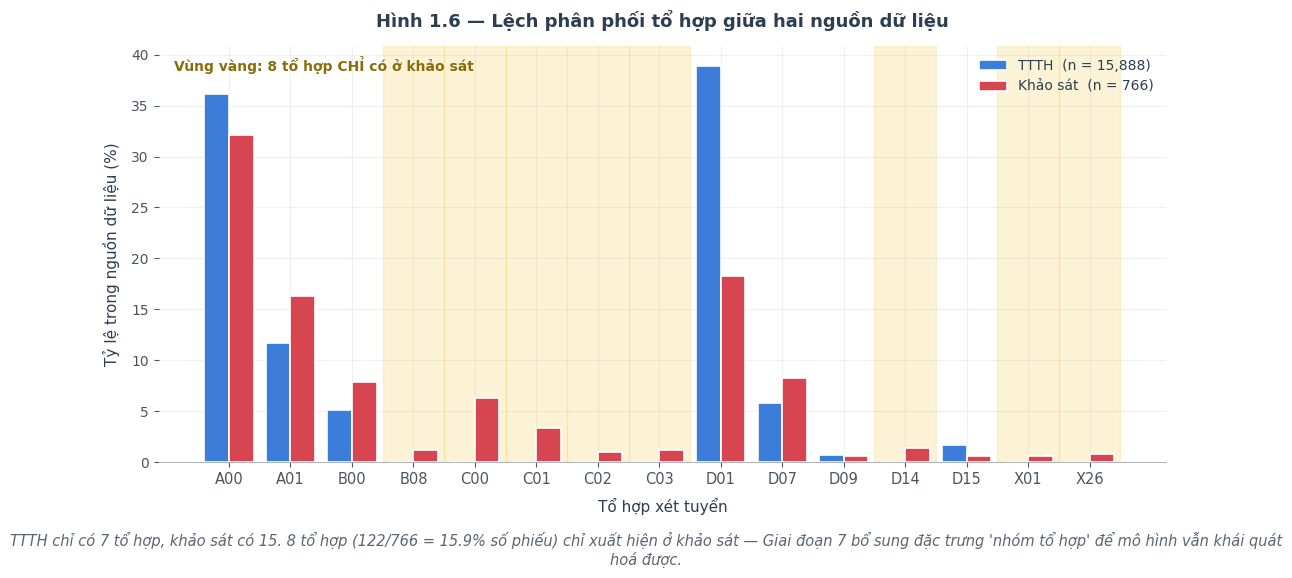

Tổ hợp trong TTTH     ( 7): ['A00', 'A01', 'B00', 'D01', 'D07', 'D09', 'D15']
Tổ hợp trong khảo sát (15): ['A00', 'A01', 'B00', 'B08', 'C00', 'C01', 'C02', 'C03', 'D01', 'D07', 'D09', 'D14', 'D15', 'X01', 'X26']
Chỉ có ở khảo sát     ( 8): ['B08', 'C00', 'C01', 'C02', 'C03', 'D14', 'X01', 'X26']


In [11]:
# ═══════════ HÌNH 1.6 — Lệch phân phối tổ hợp giữa hai nguồn ═══════════
kh_df = pd.read_csv("../data/raw/khao_sat_dinh_huong_nganh_hoc_clean.csv")
kh_th = kh_df["to_hop_thi"].astype(str).str.split().str[0]

th_ttth, th_ks = set(df_final["to_hop_thi"]), set(kh_th)
chi_ks = sorted(th_ks - th_ttth)
n_le = int(kh_th.isin(chi_ks).sum())
tat_ca = sorted(th_ttth | th_ks)

fig, ax = plt.subplots(figsize=(13, 5.4))
x = np.arange(len(tat_ca)); w = 0.4
p_ttth = np.array([(df_final["to_hop_thi"] == t).mean() for t in tat_ca]) * 100
p_ks    = np.array([(kh_th == t).mean() for t in tat_ca]) * 100

for i, t in enumerate(tat_ca):
    if t in chi_ks:
        ax.axvspan(i - 0.5, i + 0.5, color="#F5D76E", alpha=0.28, zorder=0)

ax.bar(x - w/2, p_ttth, w, label=f"TTTH  (n = {len(df_final):,})",
       color=C_XANH, edgecolor="white", linewidth=1.2)
ax.bar(x + w/2, p_ks, w, label=f"Khảo sát  (n = {len(kh_df)})",
       color=C_THAT, edgecolor="white", linewidth=1.2)

ax.set_xticks(x); ax.set_xticklabels(tat_ca, fontsize=10.5)
ax.set_ylabel("Tỷ lệ trong nguồn dữ liệu (%)"); ax.set_xlabel("Tổ hợp xét tuyển")
ax.set_title("Hình 1.6 — Lệch phân phối tổ hợp giữa hai nguồn dữ liệu")
ax.legend(loc="upper right"); ax.set_axisbelow(True)
ax.text(0.015, 0.94, f"Vùng vàng: {len(chi_ks)} tổ hợp CHỈ có ở khảo sát",
        transform=ax.transAxes, fontsize=10, color="#8A6D0B", fontweight="bold")

luu(fig, HINH_DIR, "hinh_1_6_lech_phan_phoi_to_hop.png",
    f"TTTH chỉ có {len(th_ttth)} tổ hợp, khảo sát có {len(th_ks)}. "
    f"{len(chi_ks)} tổ hợp ({n_le}/{len(kh_df)} = {n_le/len(kh_df):.1%} số phiếu) chỉ xuất hiện ở khảo sát — "
    "Giai đoạn 7 bổ sung đặc trưng 'nhóm tổ hợp' để mô hình vẫn khái quát hoá được.")
plt.show()

print(f"Tổ hợp trong TTTH     ({len(th_ttth):>2}): {sorted(th_ttth)}")
print(f"Tổ hợp trong khảo sát ({len(th_ks):>2}): {sorted(th_ks)}")
print(f"Chỉ có ở khảo sát     ({len(chi_ks):>2}): {chi_ks}")

In [12]:
# --- Xuất file ----------------------------------------------------------------
df_final.drop(columns=["ma_khoi", "diem_tb"]).to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"✅ Đã lưu {OUTPUT_PATH.name}: {len(df_final):,} dòng × 12 cột\n")
print("═" * 68)
print("  TÓM TẮT GIAI ĐOẠN 1")
print("═" * 68)
print(f"  Hồ sơ thô                    {SO_DONG_GOC:>10,}")
print(f"  Hồ sơ sau làm sạch           {len(df_final):>10,}   ({len(df_final)/SO_DONG_GOC:.1%})")
print(f"  Số ngành có dữ liệu          {df_final['ma_nganh'].nunique():>10} / 39")
print(f"  Số ngành KHÔNG có dữ liệu    {len(thieu_nganh):>10}")
print(f"  Mất cân bằng giữa các ngành  {vc.max()/vc.min():>9.0f} lần")
print(f"  Số tổ hợp xét tuyển          {len(th_ttth):>10}   (khảo sát có {len(th_ks)})")
print(f"  Điểm trung bình              {df_final['diem_tb'].mean():>10.2f} ± {df_final['diem_tb'].std():.2f}")
print("═" * 68)
print(f"\n  Hình đã lưu tại: {HINH_DIR}/")

✅ Đã lưu TTTH_processed_flatten.csv: 15,888 dòng × 12 cột

════════════════════════════════════════════════════════════════════
  TÓM TẮT GIAI ĐOẠN 1
════════════════════════════════════════════════════════════════════
  Hồ sơ thô                        18,024
  Hồ sơ sau làm sạch               15,888   (88.1%)
  Số ngành có dữ liệu                  34 / 39
  Số ngành KHÔNG có dữ liệu             5
  Mất cân bằng giữa các ngành         98 lần
  Số tổ hợp xét tuyển                   7   (khảo sát có 15)
  Điểm trung bình                    7.28 ± 0.65
════════════════════════════════════════════════════════════════════

  Hình đã lưu tại: ../data/processed/01_flatten/
